In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("C:/Users/adhee/INFOSYS/Milestones/Milestone1/data/Clean-Data")
df

,timestamp,fridge,ac,lights,microwave,total_power
0,2023-01-01 00:00:00,0,0,28,0,28.0
1,2023-01-01 01:00:00,119,0,84,0,203.0
2,2023-01-01 02:00:00,135,0,47,0,182.0
3,2023-01-01 03:00:00,171,0,21,0,192.0
4,2023-01-01 04:00:00,0,0,88,0,88.0
...,...,...,...,...,...,...
4316,2023-06-29 20:00:00,146,2221,23,0,2390.0
4317,2023-06-29 21:00:00,72,1887,31,0,1990.0
4318,2023-06-29 22:00:00,156,1982,0,0,2138.0
4319,2023-06-29 23:00:00,149,1143,43,0,1335.0


In [3]:
device_cols = ['fridge','ac','lights','microwave']
existing_device_cols = [ c for c in device_cols if c in df.columns]

<Figure size 500x500 with 0 Axes>

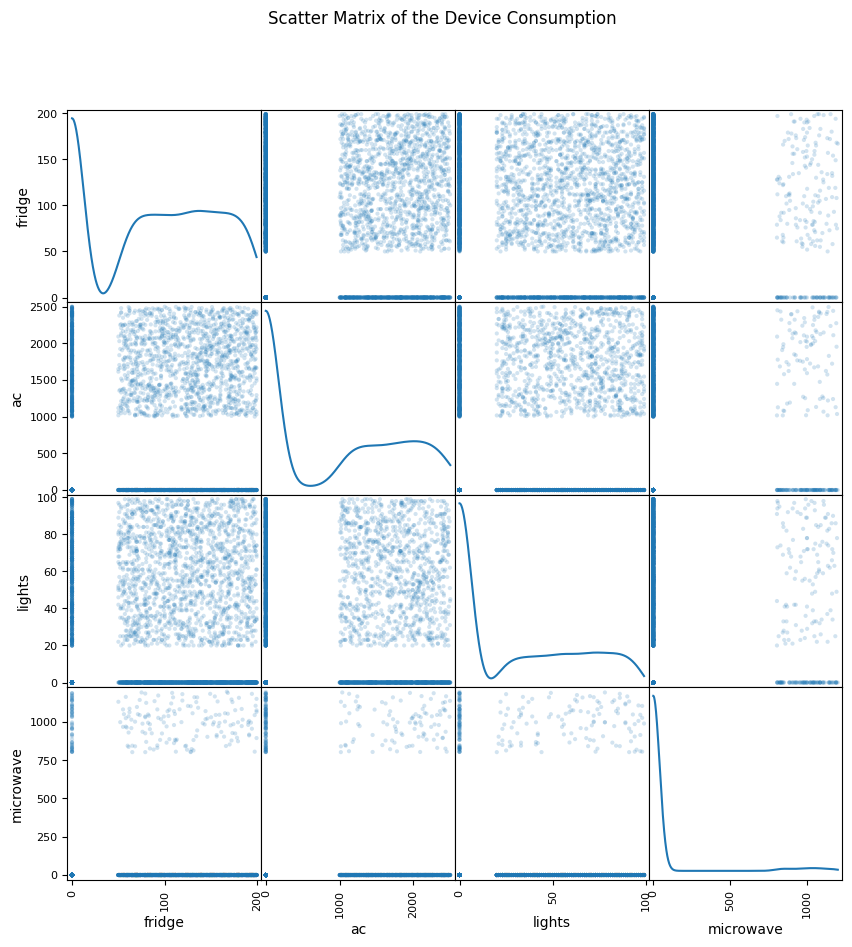

In [4]:
try:
    from pandas.plotting import scatter_matrix
    plt.figure(figsize=(5,5))
    scatter_matrix(df[existing_device_cols],alpha=0.2,figsize=(10,10),diagonal="kde")
    plt.suptitle('Scatter Matrix of the Device Consumption')
    plt.show()
except Exception as e:
    print(f"Could not plot a Scatter matrix: {e}")

Granger Casuality Test: AC ---> Total Power


C:\Users\adhee\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


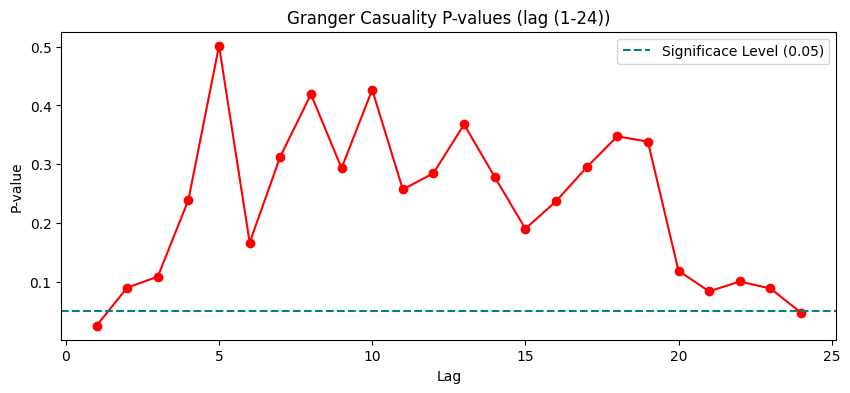

In [6]:
from statsmodels.tsa.stattools import grangercausalitytests
if 'ac' in df.columns and 'total_power' in df.columns:
    data_gc = df[['total_power','fridge']].dropna()
    print("Granger Casuality Test: fridge ---> Total Power")
    gc_res = grangercausalitytests(data_gc,maxlag=24, verbose=False)

    p_values = [gc_res[i+1][0]['ssr_chi2test'][1] for i in range(24)]
    plt.figure(figsize = (10,4))
    plt.plot(range(1,25),p_values,marker='o',color = "red")
    plt.axhline(0.05,color="teal",linestyle = '--',label = 'Significace Level (0.05)')
    plt.title("Granger Casuality P-values (lag (1-24))")
    plt.xlabel('Lag')
    plt.ylabel('P-value')
    plt.legend()
    plt.show()  

Granger Casuality Test: AC ---> Total Power


C:\Users\adhee\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


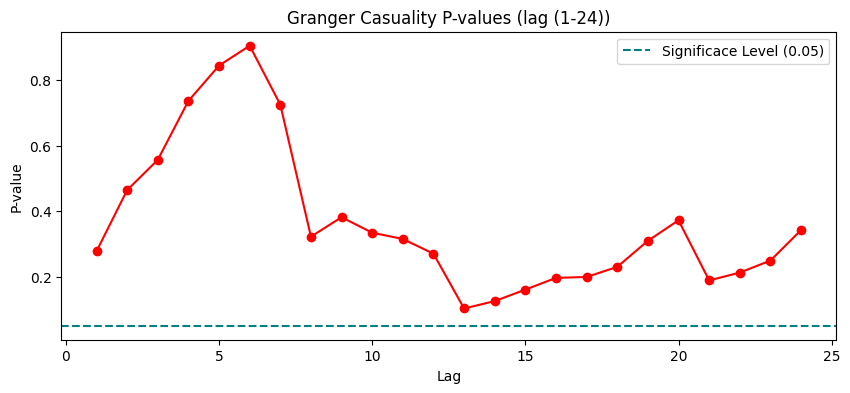

In [10]:
from statsmodels.tsa.stattools import grangercausalitytests
if 'ac' in df.columns and 'total_power' in df.columns:
    data_gc = df[['total_power','lights']].dropna()
    print("Granger Casuality Test: AC ---> Total Power")
    gc_res = grangercausalitytests(data_gc,maxlag=24, verbose=False)

    p_values = [gc_res[i+1][0]['ssr_chi2test'][1] for i in range(24)]
    plt.figure(figsize = (10,4))
    plt.plot(range(1,25),p_values,marker='o',color = "red")
    plt.axhline(0.05,color="teal",linestyle = '--',label = 'Significace Level (0.05)')
    plt.title("Granger Casuality P-values (lag (1-24))")
    plt.xlabel('Lag')
    plt.ylabel('P-value')
    plt.legend()
    plt.show()  